In [ ]:
## regplot and cross_val_score

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [64]:
df_index = pd.read_csv("economic_index.csv")

In [65]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [66]:
## drop the unnecessary columns
df_index.drop(columns=["Unnamed: 0", "year", "month"], axis=1, inplace= True)


In [67]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [68]:
## check is there anny null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

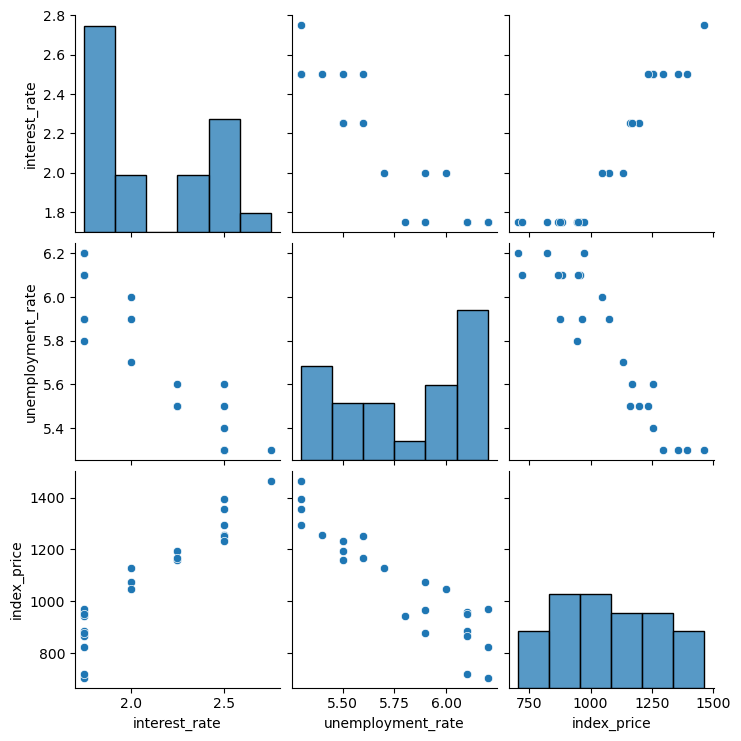

In [69]:
import seaborn as sns
sns.pairplot(df_index)

In [70]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment rate')

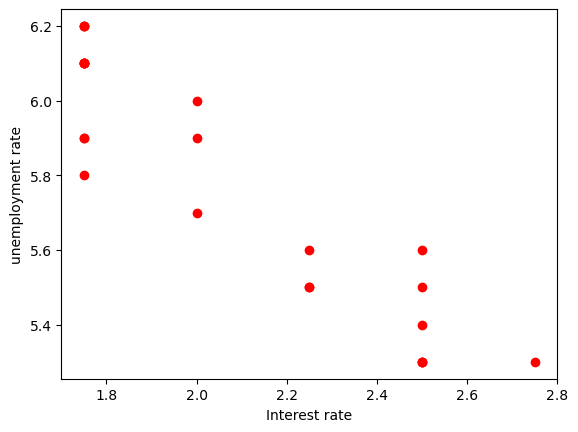

In [71]:
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='r')
plt.xlabel("Interest rate")
plt.ylabel("unemployment rate")

In [ ]:
## seperating independent and dependent features
##X = df_index[['interest_rate', 'unemployment_rate']] 
## OR

X = df_index.iloc[:,:-1] ## take all rows except last rows - independent feature
y = df_index.iloc[:, -1] ## take the last column - dependent feature.

In [73]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [74]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [75]:
## train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [76]:
import seaborn as sns

<Axes: xlabel='interest_rate', ylabel='index_price'>

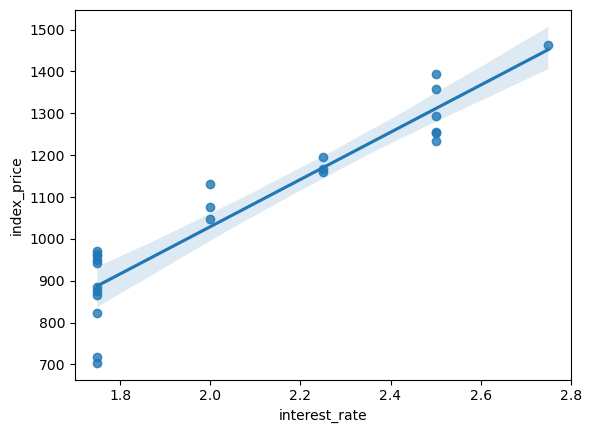

In [77]:
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])
## the show shows that , the fit linecan vary between this shadows.

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

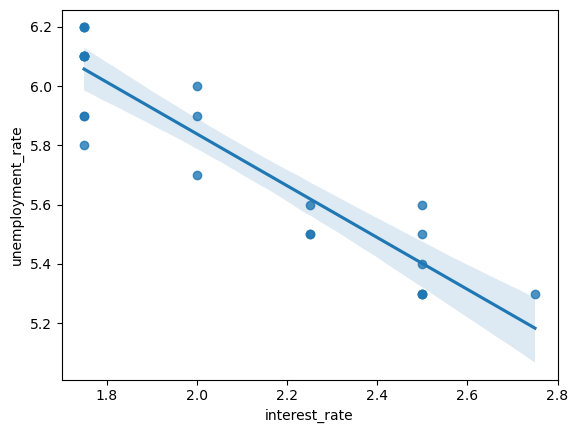

In [78]:

sns.regplot(x=df_index['interest_rate'],y=df_index['unemployment_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

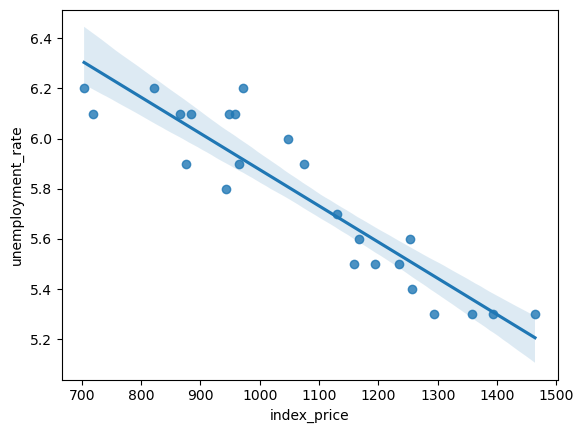

In [79]:
sns.regplot(x=df_index['index_price'],y=df_index['unemployment_rate'])

In [80]:
from sklearn.preprocessing import StandardScaler


In [81]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [82]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [83]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [84]:
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [85]:
## cross validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regressor, X_train, y_train, scoring = 'neg_mean_squared_error', cv=3)

In [86]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [87]:
np.mean(validation_score)

np.float64(-5914.828180162396)

In [88]:
print(X_train.shape)
print(y_train.shape)

(18, 2)
(18,)


In [89]:
## the below code will not work...because there are more then 1 features.
##plt.scatter(X_train,y_train)
##plt.plot(X_train, regressor.predict(X_train))

In [90]:
## prediction
y_pred=regressor.predict(X_test)

In [91]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [92]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.76288771258
59.93578152323556
76.11677139574813


In [93]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
#display adjusted R-squared
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.8278978091457142
0.713163015242857


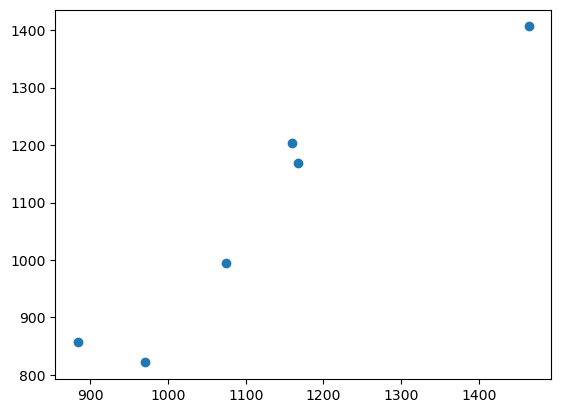

In [94]:
plt.scatter(y_test,y_pred)

In [95]:
residuals=y_test-y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


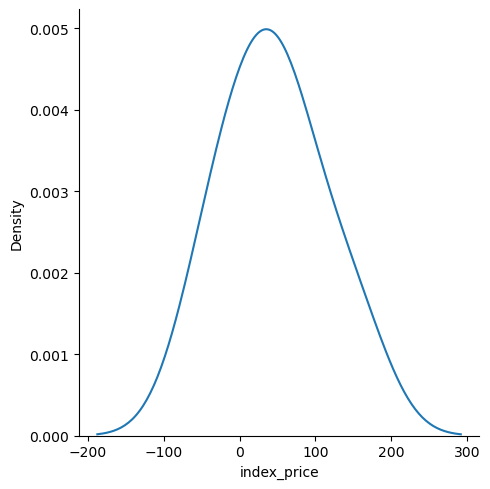

In [96]:
## Plot this residuals
sns.displot(residuals,kind='kde')

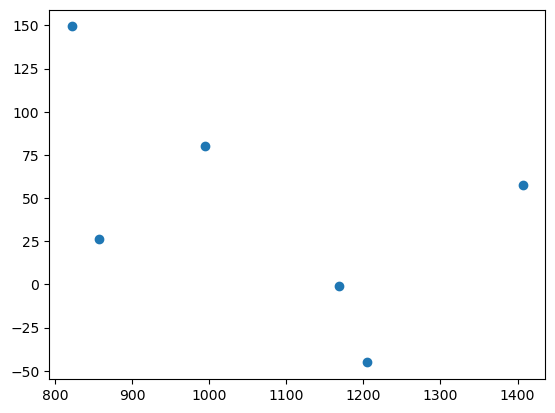

In [97]:

## scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)
## if the below plot is random then it is good...if follows some pattern then not good

In [98]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [99]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Thu, 09 Jul 2026   Prob (F-statistic):                       0.754
Time:                        14:55:55   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [100]:
print(regressor.coef_)

[  88.27275507 -116.25716066]
